In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("ecommerce_customer_data_custom_ratios.csv")

In [3]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [4]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

In [5]:
df = df.drop(['Customer Age'], axis=1)
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])
df.isnull().sum()

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Returns                  47596
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

In [6]:
df['Total Purchase Amount'].sum()

681342683

In [7]:
df['Total Purchase Amount'].mean()

2725.370732

In [8]:
df['Product Category'].value_counts()

Product Category
Clothing       75052
Books          74912
Electronics    50185
Home           49851
Name: count, dtype: int64

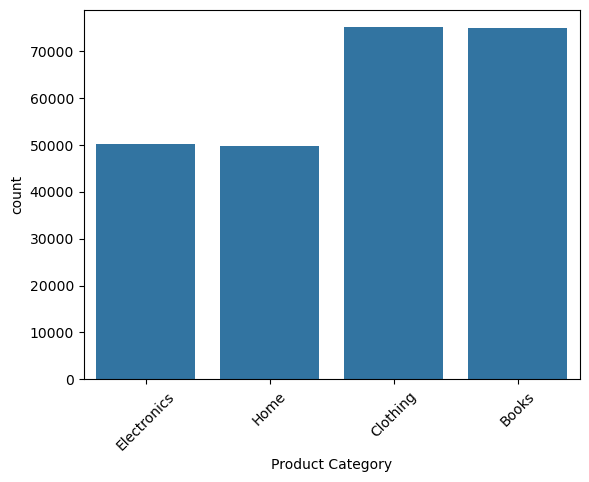

In [9]:
sns.countplot(data=df, x='Product Category')
plt.xticks(rotation=45)
plt.show()

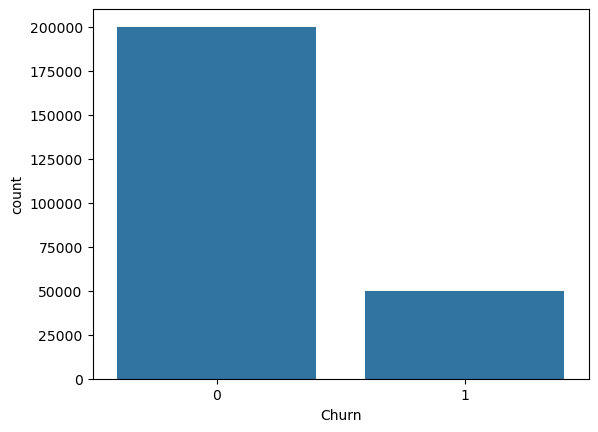

In [10]:
sns.countplot(data=df, x='Churn')
plt.show()

In [11]:
snapshot_date = df['Purchase Date'].max() + pd.Timedelta(days=1)

In [12]:
rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (snapshot_date - x.max()).days,
    'Customer ID': 'count',
    'Total Purchase Amount': 'sum'
})
rfm.rename(columns={
    'Purchase Date': 'Recency',
    'Customer ID': 'Frequency',
    'Total Purchase Amount': 'Monetary'
}, inplace=True)

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
1,58,1,3491
2,299,3,7988
3,89,8,22587
4,127,4,8715
5,171,8,12524


In [13]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'], 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

In [14]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

In [15]:
def segment(row):
    if row['RFM_Score'] == '444':
        return 'Best Customers'
    elif row['R_score'] == 4:
        return 'Recent Customers'
    elif row['F_score'] == 4:
        return 'Loyal Customers'
    elif row['M_score'] == 4:
        return 'Big Spenders'
    else:
        return 'At Risk'

rfm['Segment'] = rfm.apply(segment, axis=1)

In [16]:
rfm['Segment'].value_counts()

Segment
At Risk             27472
Recent Customers     8948
Loyal Customers      7343
Best Customers       3569
Big Spenders         2341
Name: count, dtype: int64

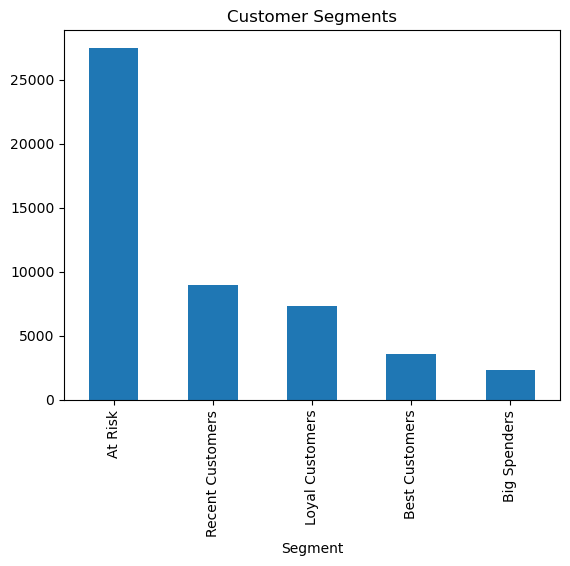

In [17]:
rfm['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segments")
plt.show()

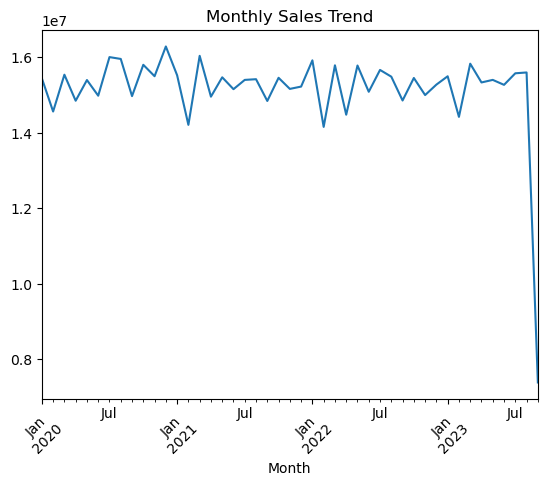

In [18]:
df['Month'] = df['Purchase Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Total Purchase Amount'].sum()

monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.show()

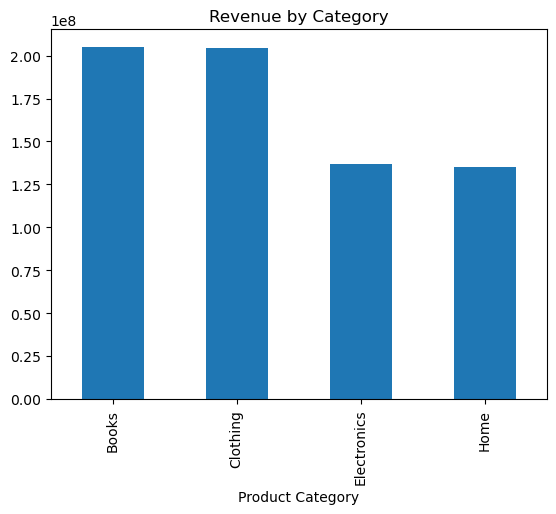

In [19]:
category_sales = df.groupby('Product Category')['Total Purchase Amount'].sum()

category_sales.sort_values(ascending=False).plot(kind='bar')
plt.title("Revenue by Category")
plt.show()

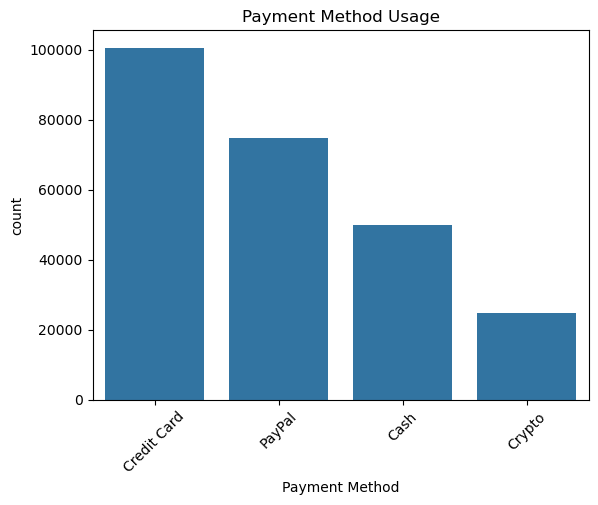

In [23]:
sns.countplot(data=df, x='Payment Method')
plt.title("Payment Method Usage")
plt.xticks(rotation=45)
plt.show()

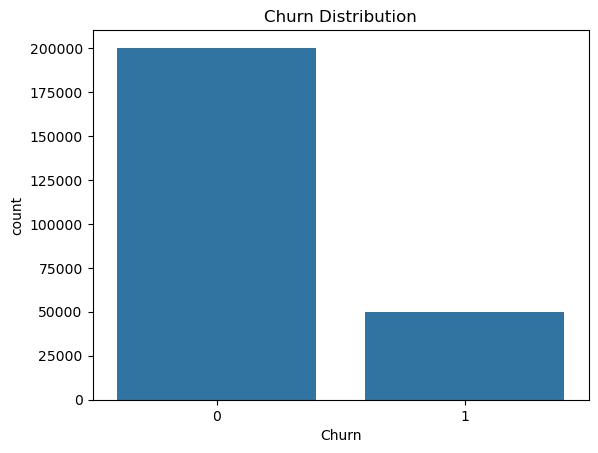

In [24]:
sns.countplot(data=df, x='Churn')
plt.title("Churn Distribution")
plt.show()

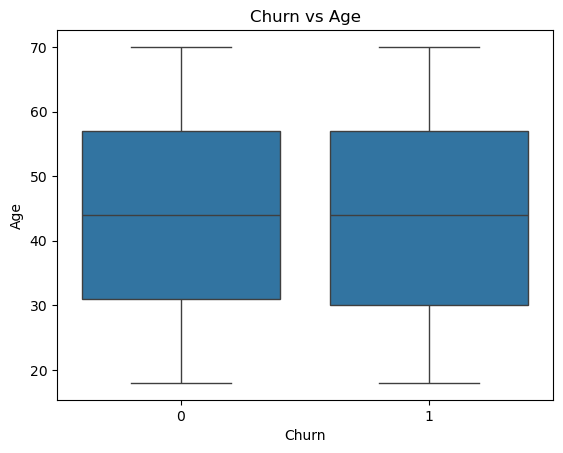

In [25]:
sns.boxplot(data=df, x='Churn', y='Age')
plt.title("Churn vs Age")
plt.show()

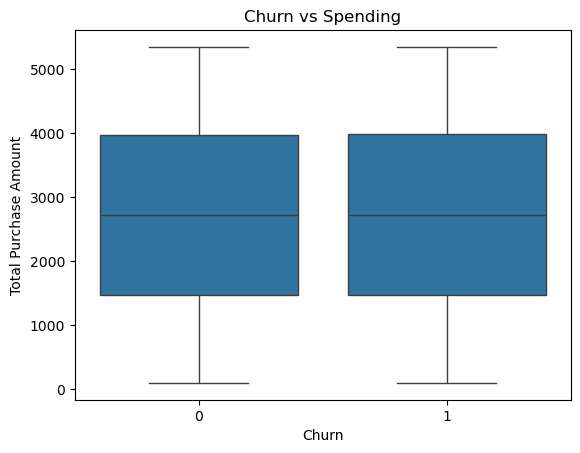

In [26]:
sns.boxplot(data=df, x='Churn', y='Total Purchase Amount')
plt.title("Churn vs Spending")
plt.show()

In [27]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100
churn_rate

Churn
0    80.0504
1    19.9496
Name: proportion, dtype: float64